In [2]:
pip install tqdm

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import os
import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
from netCDF4 import Dataset as ncDataset
from tqdm import tqdm
import copy
import gc
import xarray as xr
import glob
from scipy.stats import gamma, norm
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

In [2]:
#############################################
# 1. Dataset 정의 (일별 강수량 자료 로딩)
#############################################
class RainfallDataset(Dataset):
    def __init__(self, low_res_folder, high_res_folder, dem_file, start_date, end_date):
        self.low_res_folder = low_res_folder
        self.high_res_folder = high_res_folder
        self.dem_file = dem_file
        self.dates = [start_date + datetime.timedelta(days=i) 
                      for i in range((end_date - start_date).days + 1)]
        self.valid_data = self._filter_valid_data()
        self.dem_data = self._load_dem_data()
    
    def __len__(self):
        return len(self.valid_data)
    
    def __getitem__(self, idx):
        try:
            date = self.valid_data[idx]
            low_res_file = os.path.join(self.low_res_folder, date.strftime("%Y%m%d") + ".nc4")
            high_res_file = os.path.join(self.high_res_folder, date.strftime("%Y.%m.%d") + "_Cokriging_Precipitation.nc")
            
            low_res_data = self.load_and_resize_nc_file(low_res_file, 'precipitation', target_shape=(61, 101))
            high_res_data = self.load_nc_file(high_res_file, 'precipitation')
            dem_data = self.dem_data
            
            if low_res_data is None or high_res_data is None:
                raise FileNotFoundError(f"Missing data for date {date.strftime('%Y-%m-%d')}")
            
            # Normalize data
            low_res_data = self.normalize_data(low_res_data)
            dem_data = self.normalize_data(dem_data)
            
            # Add month as sine and cosine
            month = date.month
            month_sin = np.sin(2 * np.pi * month / 12)
            month_cos = np.cos(2 * np.pi * month / 12)
            
            month_sin_map = np.full(low_res_data.shape, month_sin, dtype=np.float32)
            month_cos_map = np.full(low_res_data.shape, month_cos, dtype=np.float32)
            
            low_res_data = torch.tensor(low_res_data, dtype=torch.float32).unsqueeze(0)
            high_res_data = torch.tensor(high_res_data, dtype=torch.float32).unsqueeze(0)
            dem_data = torch.tensor(dem_data, dtype=torch.float32).unsqueeze(0)
            month_sin_map = torch.tensor(month_sin_map, dtype=torch.float32).unsqueeze(0)
            month_cos_map = torch.tensor(month_cos_map, dtype=torch.float32).unsqueeze(0)
            
            # Combine channels: low_res, dem, sin(month), cos(month)
            input_data = torch.cat([low_res_data, dem_data, month_sin_map, month_cos_map], dim=0)
            
            return input_data, high_res_data
        except Exception as e:
            print(f"Error in __getitem__ for index {idx}: {str(e)}")
            raise e
    
    def normalize_data(self, data):
        mean = np.mean(data)
        std = np.std(data)
        if std == 0:
            return data - mean
        return (data - mean) / (std + 1e-8)
    
    def load_nc_file(self, file_path, var_name):
        try:
            with ncDataset(file_path, 'r') as nc_file:
                data = nc_file.variables[var_name][:].astype(np.float32)
                return data
        except FileNotFoundError:
            print(f"File {file_path} not found.")
            return None
        except Exception as e:
            print(f"Error loading {file_path}: {str(e)}")
            return None
    
    def load_and_resize_nc_file(self, file_path, var_name, target_shape):
        try:
            with ncDataset(file_path, 'r') as nc_file:
                data = nc_file.variables[var_name][:].astype(np.float32)
                if len(data.shape) == 3:
                    data = data.squeeze(0)
                data = torch.tensor(data, dtype=torch.float32)
                data = F.interpolate(
                    data.unsqueeze(0).unsqueeze(0), 
                    size=target_shape, 
                    mode='bilinear', 
                    align_corners=False
                ).squeeze()
                return data.numpy()
        except FileNotFoundError:
            print(f"File {file_path} not found.")
            return None
        except Exception as e:
            print(f"Error resizing {file_path}: {str(e)}")
            return None
    
    def _filter_valid_data(self):
        valid_dates = []
        for date in self.dates:
            low_res_file = os.path.join(self.low_res_folder, date.strftime("%Y%m%d") + ".nc4")
            high_res_file = os.path.join(self.high_res_folder, date.strftime("%Y.%m.%d") + "_Cokriging_Precipitation.nc")
            if os.path.exists(low_res_file) and os.path.exists(high_res_file):
                valid_dates.append(date)
        return valid_dates
    
    def _load_dem_data(self):
        try:
            with rasterio.open(self.dem_file) as dem_src:
                dem_data = dem_src.read(1)
                dem_data = self.normalize_data(dem_data)
                dem_data = torch.tensor(dem_data, dtype=torch.float32)
                dem_data = F.interpolate(
                    dem_data.unsqueeze(0).unsqueeze(0), 
                    size=(61, 101), 
                    mode='bilinear', 
                    align_corners=False
                ).squeeze()
                return dem_data.numpy()
        except FileNotFoundError:
            print(f"DEM file {self.dem_file} not found.")
            return None
        except Exception as e:
            print(f"Error loading DEM file {self.dem_file}: {str(e)}")
            return None


In [3]:
# -------------------------------------------------------------------
# (0) SPI 계산 함수
# -------------------------------------------------------------------
def compute_spi(monthly_precip_da: xr.DataArray, scale: int = 3) -> xr.DataArray:
    """
    monthly_precip_da: DataArray(time, lat, lon) 월별 누적강수량
    scale: 누적할 개월 수 (예: 3)
    """
    # 1) rolling sum
    roll = monthly_precip_da.rolling(time=scale, min_periods=scale).sum()

    # SPI 결과용 빈 DataArray 준비
    spi = xr.full_like(roll, np.nan)
    lats = roll.lat.values
    lons = roll.lon.values

    # 그리드별로 순회
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            series = roll[:, i, j].values
            mask = np.isfinite(series)
            data = series[mask]
            if data.size < scale:
                continue

            # 영(0) 값 비율
            p0 = np.sum(data == 0) / data.size
            pos = data[data > 0]
            if pos.size < scale:
                continue

            # 감마 분포 적합 (loc=0 고정)
            alpha, loc, beta = stats.gamma.fit(pos, floc=0)

            # CDF 계산
            cdf = np.empty_like(data, dtype=float)
            for k, v in enumerate(data):
                if v <= 0:
                    cdf[k] = p0 / 2
                else:
                    cdf[k] = p0 + (1 - p0) * stats.gamma.cdf(v, alpha, loc=loc, scale=beta)
            cdf = np.clip(cdf, 1e-6, 1 - 1e-6)

            # 정규 분포 분위수로 변환
            spi_vals = stats.norm.ppf(cdf)

            arr = spi[:, i, j].values
            arr[mask] = spi_vals
            spi[:, i, j] = arr

    spi.name = "SPI"
    spi.attrs["long_name"] = f"SPI-{scale}"
    spi.attrs["units"] = "standardized units"
    return spi

In [4]:
#############################################
# 2. GAN Generator (Downscaling 추론용; Discriminator는 불필요)
#############################################
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )
        # Enhanced attention module
        self.attention = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.Sigmoid()
        )
        # Rainfall amplification branch
        self.rainfall_amp = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # Enhanced rainfall intensity layer with skip connections
        self.enhancement = nn.ModuleList([
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 1, kernel_size=1)
        ])
    
    def forward(self, x, target_shape):
        enc = self.encoder(x)
        att = self.attention(enc)
        enc_att = enc * att
        amp = self.rainfall_amp(enc_att)
        dec = self.decoder(enc_att)
        enhanced = dec
        for i, layer in enumerate(self.enhancement):
            if i == len(self.enhancement) - 1:
                enhanced = layer(enhanced) + amp
            else:
                enhanced = F.relu(layer(enhanced))
        enhanced = F.relu(enhanced) * 1.2
        output = F.interpolate(enhanced, size=target_shape, mode='bilinear', align_corners=False)
        return output

In [5]:
#############################################
# 3. Downscaling: 학습된 GAN generator를 이용해 일별 강수량 예측 (nc파일 저장)
#############################################
def downscale_data(low_res_folder, high_res_folder, dem_file, start_date, end_date, 
                   model_path, output_folder, target_shape=(61, 101)):
    dataset = RainfallDataset(low_res_folder, high_res_folder, dem_file, start_date, end_date)
    data_loader = DataLoader(dataset, batch_size=1, shuffle=False, pin_memory=True)
    
    # output_folder가 없으면 생성
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    generator = Generator().cuda()
    checkpoint = torch.load(model_path)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    generator.eval()
    
    predictions = []
    dates = dataset.valid_data  # valid한 날짜 리스트
    
    print("Downscaling (inference) 시작...")
    with torch.no_grad():
        for low_res, _ in tqdm(data_loader, desc="Downscaling"):
            low_res = low_res.cuda()
            output = generator(low_res, target_shape)
            pred = output.cpu().squeeze().numpy()
            predictions.append(pred)
    
    save_predictions_to_nc(predictions, dates, output_folder)
    print("Downscaling 완료 및 nc파일 저장됨.")
    return predictions, dates

def save_predictions_to_nc(predictions, dates, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Jeju 지역 (예시)
    jeju_lat_start, jeju_lat_end = 33.1, 33.6
    jeju_lon_start, jeju_lon_end = 126.1, 127.1
    
    lat_vals = np.linspace(jeju_lat_start, jeju_lat_end, predictions[0].shape[0])
    lon_vals = np.linspace(jeju_lon_start, jeju_lon_end, predictions[0].shape[1])
    
    for pred, date in zip(predictions, dates):
        filename = os.path.join(output_folder, f"{date.strftime('%Y%m%d')}_GAN_Prediction.nc")
        try:
            with ncDataset(filename, 'w', format='NETCDF4') as nc:
                nc.createDimension('latitude', pred.shape[0])
                nc.createDimension('longitude', pred.shape[1])
                
                lats = nc.createVariable('latitude', 'f4', ('latitude',))
                lons = nc.createVariable('longitude', 'f4', ('longitude',))
                precip = nc.createVariable('precipitation', 'f4', ('latitude', 'longitude'))
                
                lats[:] = lat_vals
                lons[:] = lon_vals
                precip[:, :] = pred
                
                nc.description = 'GAN Downscaled Precipitation Prediction with DEM and Seasonal Encoding'
                nc.date = date.strftime('%Y-%m-%d')
            print(f"저장 성공: {date.strftime('%Y-%m-%d')}")
        except Exception as e:
            print(f"{date.strftime('%Y-%m-%d')} 예측 저장 실패: {str(e)}")

In [6]:
#############################################
# 4. 집계: 일별 nc파일들을 월별 강수량 자료로 개별 저장 (파일명: yyyymm_GAN_Prediction.nc)
#############################################
def aggregate_daily_to_monthly_individual(input_folder, monthly_output_folder):
    """
    input_folder: 일별 예측 nc파일들이 저장된 폴더 (파일명: yyyymmdd_GAN_Prediction.nc)
    monthly_output_folder: 월별 자료 저장 폴더
    """
    if not os.path.exists(monthly_output_folder):
        os.makedirs(monthly_output_folder)
    
    file_list = sorted(glob.glob(os.path.join(input_folder, "*_GAN_Prediction.nc")))
    
    # 그룹핑: (year, month) 별로 파일 모으기
    monthly_dict = {}
    for file in file_list:
        base = os.path.basename(file)
        try:
            # 파일명에서 날짜 추출 (예: 20160115_GAN_Prediction.nc)
            date = datetime.datetime.strptime(base[:8], "%Y%m%d")
        except Exception as e:
            print(f"파일명 {base}에서 날짜 추출 오류: {e}")
            continue
        ym = date.strftime("%Y%m")
        monthly_dict.setdefault(ym, []).append(file)
    
    monthly_dataarrays = []
    time_list = []
    
    # 각 월별로 일별 파일 읽어 합산
    for ym, files in sorted(monthly_dict.items()):
        daily_da_list = []
        for file in files:
            try:
                ds = xr.open_dataset(file)
                # 변수명이 'precipitation'라고 가정
                da = ds['precipitation']
                daily_da_list.append(da)
                ds.close()
            except Exception as e:
                print(f"{file} 처리 오류: {e}")
        if daily_da_list:
            # 시간 축이 없는 DataArray들이면 expand_dims로 추가 후 합산
            daily_concat = xr.concat([da.expand_dims(time=[0]) if 'time' not in da.dims else da for da in daily_da_list], dim="time")
            # 월별 누적합 계산 (모든 일의 합)
            monthly_sum = daily_concat.sum(dim="time")
            # 시간 좌표는 해당 월의 첫날로 지정
            time_val = np.datetime64(datetime.datetime.strptime(ym, "%Y%m"))
            monthly_sum = monthly_sum.expand_dims(time=[time_val])
            monthly_sum = monthly_sum.rename("precipitation")
            monthly_dataarrays.append(monthly_sum)
            time_list.append(time_val)
            # 저장: 파일명 yyyymm_GAN_Prediction.nc
            out_filename = os.path.join(monthly_output_folder, f"{ym}_GAN_Prediction.nc")
            ds_month = monthly_sum.to_dataset()
            ds_month.to_netcdf(out_filename)
            print(f"월별 자료 저장 완료: {out_filename}")
    
    # Combine all monthly DataArrays into one dataset for further processing
    if monthly_dataarrays:
        monthly_ds = xr.concat(monthly_dataarrays, dim="time")
        monthly_ds = monthly_ds.assign_coords(time=("time", sorted(time_list)))
        return monthly_ds
    else:
        return None

In [ ]:
#############################################
# Main 실행 파트
#############################################
if __name__ == "__main__":
    # -----------------------------
    # 설정: 자료 경로, 날짜 범위 등
    # -----------------------------
    start_date = datetime.date(2016, 1, 1)
    end_date = datetime.date(2023, 12, 31)
    
    # 폴더 및 파일 경로 (사용자 환경에 맞게 수정)
    low_res_folder = r'G:\24.11.Graduate\0.Rawdata\GPM_IMERG_Clipped'
    high_res_folder = r'G:\24.11.Graduate\1.CoKriging'
    dem_file = r"G:\24.11.Graduate\DEM_Jeju.tif"
    output_folder = r'C:\Yeonji\2025.01.Drought\Output(new)'
    model_path = r"G:\24.11.Graduate\2.GAN_Predictions(7)\gan_model_seasonal.pth"
    
    # output_folder가 없으면 생성
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # (1) Downscaling: 일별 강수량 예측 파일 생성 (파일명: yyyymmdd_GAN_Prediction.nc)
    print("1. Downscaling 시작...")
    predictions, valid_dates = downscale_data(low_res_folder, high_res_folder, dem_file,
                                              start_date, end_date, model_path, output_folder,
                                              target_shape=(61, 101))
    
    # (2) 집계: 일별 nc파일들을 월별 자료로 개별 저장 (파일명: yyyymm_GAN_Prediction.nc)
    monthly_folder = os.path.join(output_folder, "Monthly")
    if not os.path.exists(monthly_folder):
        os.makedirs(monthly_folder)
    monthly_ds = aggregate_daily_to_monthly_individual(output_folder, monthly_folder)
    if monthly_ds is None:
        print("월별 자료 집계 실패.")
        exit(1)
    
    # 반환된 monthly_ds가 DataArray이면 그대로 사용, 아니면 'precipitation' 변수 추출
    if isinstance(monthly_ds, xr.DataArray):
        monthly_precip = monthly_ds
    else:
        monthly_precip = monthly_ds['precipitation']
    
    # (3) SPI (3개월) 계산 (전통적 방식) - 월별 강수량 자료 사용
    spi_da = compute_spi(monthly_precip, scale=3)
    
    # SPI 결과를 개별 월별 파일로 저장 (파일명: yyyymm_GAN_SPI3.nc)
    spi_output_folder = os.path.join(output_folder, "SPI")
    if not os.path.exists(spi_output_folder):
        os.makedirs(spi_output_folder)
    
    for t in range(spi_da.shape[0]):
        time_val = pd.to_datetime(str(spi_da.time.values[t])).strftime("%Y%m")
        spi_slice = spi_da.isel(time=t)
        out_file = os.path.join(spi_output_folder, f"{time_val}_GAN_SPI3.nc")
        ds_spi = spi_slice.to_dataset(name="SPI")
        ds_spi.to_netcdf(out_file)
        print(f"SPI 저장 완료: {out_file}")
    
    torch.cuda.empty_cache()
    gc.collect()
    print("전체 파이프라인 완료!")

KeyboardInterrupt: 

In [3]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt

# 입력 폴더: .nc 파일들이 저장된 폴더
input_folder = r"C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)"

# 출력 폴더: PNG 파일들을 저장할 폴더
output_png_folder =  r"C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)"
if not os.path.exists(output_png_folder):
    os.makedirs(output_png_folder)

# 입력 폴더의 모든 .nc 파일 검색
nc_files = glob.glob(os.path.join(input_folder, "*.nc"))

if not nc_files:
    print("입력 폴더에 .nc 파일이 없습니다.")
else:
    print(f"총 {len(nc_files)} 개의 .nc 파일을 찾았습니다.")

# 각 파일별로 시각화
for nc_file in nc_files:
    try:
        ds = xr.open_dataset(nc_file)
        # 변수 이름이 "SPI"가 아니면, ds.data_vars에서 첫번째 변수 사용
        if "precipitation" in ds.data_vars:
            da = ds["precipitation"]
        else:
            da = list(ds.data_vars.values())[0]
        
        # 데이터가 time 차원이 있을 경우 첫 번째 시간 슬라이스 선택 (또는 평균 등으로 처리)
        if "time" in da.dims:
            # 시간 차원이 2개 이상 있을 경우 첫 번째 슬라이스 선택
            da_plot = da.isel(time=0)
            title_time = str(da.time.values[0])
        else:
            da_plot = da
            title_time = ""
        
        plt.figure(figsize=(8, 6))
        # xarray plot() 사용 (robust 옵션은 이상치 영향을 줄여줌)
        im = da_plot.plot(cmap="RdBu_r", robust=True, add_colorbar=True)
        plt.title(f"{os.path.basename(nc_file)}\n{title_time}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        
        # 저장할 PNG 파일 경로 (확장자 .png)
        base_name = os.path.splitext(os.path.basename(nc_file))[0]
        png_file = os.path.join(output_png_folder, base_name + ".png")
        plt.savefig(png_file, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"PNG 저장 완료: {png_file}")
    except Exception as e:
        print(f"{nc_file} 처리 중 오류 발생: {e}")


총 238 개의 .nc 파일을 찾았습니다.
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200403_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200404_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200405_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200406_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200407_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200408_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200409_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200410_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200411_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200412_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200501_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200502_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.01.Drought/2004/SPI3(GAN)(png)\200503_SPI3.png
PNG 저장 완료: C:/Yeonji/2025.0

총 7305 개의 .nc 파일을 찾았습니다.
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040101_Cokriging_Precipitation.png


C:\Users\정연지\AppData\Local\Temp\ipykernel_26028\3148117773.py:67: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200, bbox_inches="tight")
C:\Users\정연지\AppData\Local\Temp\ipykernel_26028\3148117773.py:67: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200, bbox_inches="tight")
C:\Users\정연지\AppData\Local\Temp\ipykernel_26028\3148117773.py:67: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200, bbox_inches="tight")


PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040102_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040103_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040104_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040105_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040106_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040107_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040108_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040109_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\20040110_Cokriging_Precipitation.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)\2004011

KeyboardInterrupt: 

c:\ProgramData\Anaconda3\envs\YJ\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ProgramData\Anaconda3\envs\YJ\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ProgramData\Anaconda3\envs\YJ\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ProgramData\Anaconda3\envs\YJ\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\Anaconda3\envs\YJ\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\A

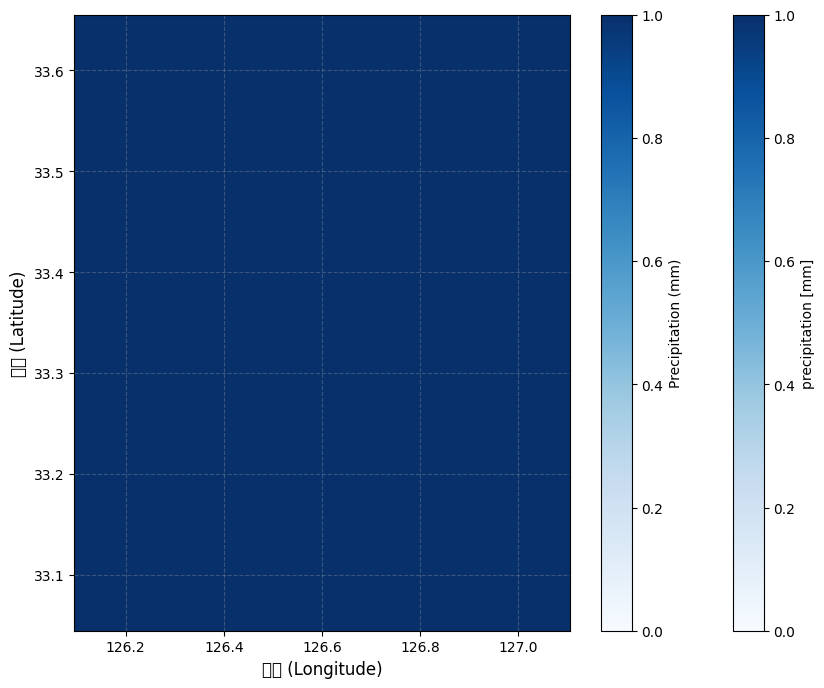

In [2]:
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# 입력 폴더: .nc 파일들이 저장된 폴더
input_folder = r"C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)"

# 출력 폴더: PNG 파일들을 저장할 폴더
output_png_folder =  r"C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)(png)"
if not os.path.exists(output_png_folder):
    os.makedirs(output_png_folder)

# 입력 폴더의 모든 .nc 파일 검색
nc_files = glob.glob(os.path.join(input_folder, "*.nc"))

if not nc_files:
    print("입력 폴더에 .nc 파일이 없습니다.")
else:
    print(f"총 {len(nc_files)} 개의 .nc 파일을 찾았습니다.")

# 각 파일별로 시각화
for nc_file in nc_files:
    try:
        # 파일 이름에서 날짜 추출 (YYYYMMDD)
        filename = os.path.basename(nc_file)
        date_str = filename.split('_')[0]  # YYYYMMDD 형식 추출
        
        # xarray로 데이터 로드
        ds = xr.open_dataset(nc_file)
        
        # precipitation 변수가 있는지 확인
        if "precipitation" in ds.data_vars:
            da = ds["precipitation"]
        else:
            # 첫 번째 변수 사용
            da = list(ds.data_vars.values())[0]
            print(f"'precipitation' 변수가 없어 {list(ds.data_vars.keys())[0]} 변수를 시각화합니다.")
        
        # 결측값 확인
        missing_pct = (np.isnan(da.values).sum() / da.size) * 100
        if missing_pct > 0:
            print(f"{filename}: 결측값 비율 {missing_pct:.2f}%")
        
        # 강수 데이터 범위를 고려한 색상 맵 설정
        plt.figure(figsize=(10, 8))
        
        # 0값이 많은 강수 데이터를 위한 설정
        vmax = np.nanpercentile(da.values, 99)  # 이상치 제외
        
        # 강수량에 적합한 색상맵 사용 (Blues는 강수에 적합)
        im = da.plot(cmap="Blues", vmin=0, vmax=vmax, add_colorbar=True)
        plt.colorbar(im, label="Precipitation (mm)")
        
        # 제목 및 축 레이블 설정
        formatted_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"
        #plt.title(f"제주도 상세 강수량 예측 (Co-kriging)\n{formatted_date}", fontsize=14)
        plt.xlabel("경도 (Longitude)", fontsize=12)
        plt.ylabel("위도 (Latitude)", fontsize=12)
        
        # 격자선 추가
        plt.grid(alpha=0.3, linestyle='--')
        
        # 저장할 PNG 파일 경로
        png_file = os.path.join(output_png_folder, os.path.splitext(filename)[0] + ".png")
        plt.savefig(png_file, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"PNG 저장 완료: {png_file}")
        
    except Exception as e:
        print(f"{nc_file} 처리 중 오류 발생: {e}")

print("시각화 작업 완료!")